In [1]:
import pandas as pd
import numpy as np
import json
import os
import sys

# Find repo root
_root = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(_root, "LLM_models_interface")):
    _root = os.path.dirname(_root)

OFFICIAL_MODES = ['1.1','1.2','1.3','1.4','1.5','2.1','2.2','2.3','2.4','2.5','2.6','3.1','3.2','3.3']

# Load predictions
preds = pd.read_csv("saved_results/predictions.csv")
print("=== predictions.csv ===")
print("shape:", preds.shape)
print("columns:", list(preds.columns))
print("\nconfigs (name):", preds['name'].unique())
print("\nrows per config:")
print(preds['name'].value_counts())
print("\nfirst 3 trace_ids:", preds['trace_id'].head(3).tolist())

=== predictions.csv ===
shape: (600, 21)
columns: ['trace_id', 'model', 'name', 'tokens_in', 'tokens_out', 'latency_s', 'cost_usd', '1.1', '1.2', '1.3', '1.4', '1.5', '2.1', '2.2', '2.3', '2.4', '2.5', '2.6', '3.1', '3.2', '3.3']

configs (name): <ArrowStringArray>
['claude-sonnet-4-6_zero_shot',  'claude-sonnet-4-6_few_shot',
    'gemini-2.5-pro_zero_shot',     'gemini-2.5-pro_few_shot',
  'gemini-2.5-flash_zero_shot',   'gemini-2.5-flash_few_shot']
Length: 6, dtype: str

rows per config:
name
claude-sonnet-4-6_zero_shot    100
claude-sonnet-4-6_few_shot     100
gemini-2.5-pro_zero_shot       100
gemini-2.5-pro_few_shot        100
gemini-2.5-flash_zero_shot     100
gemini-2.5-flash_few_shot      100
Name: count, dtype: int64

first 3 trace_ids: ['AG2_GSM_Plus_Claude_27', 'Magentic_One_GPT4o_57', 'AG2_GSM_Plus_Claude_73']


In [2]:
# Build ground-truth lookup from the dataset, keyed exactly like trace_id in predictions
with open(os.path.join(_root, "data/MAST-Data/MAD_full_dataset.json")) as f:
    dataset = json.load(f)

# Reconstruct the same trace_id key used during the run:
#   is_full -> f"{record['trace']['key']}_{record['trace_id']}"
gt_lookup = {}   # trace_id -> {mode: 0/1}
for record in dataset:
    is_full = isinstance(record['trace'], dict)
    if is_full:
        tid = f"{record['trace']['key']}_{record['trace_id']}"
    else:
        tid = str(record['trace_id'])
    if "mast_annotation" in record:
        gt_lookup[tid] = {m: record["mast_annotation"].get(m, 0) for m in OFFICIAL_MODES}

print("ground-truth entries:", len(gt_lookup))

# Check how many prediction trace_ids find a match
pred_ids = set(preds['trace_id'].astype(str))
matched = pred_ids & set(gt_lookup.keys())
print(f"matched trace_ids: {len(matched)} / {len(pred_ids)}")
missing = pred_ids - set(gt_lookup.keys())
if missing:
    print("UNMATCHED (first 5):", list(missing)[:5])

ground-truth entries: 1242
matched trace_ids: 100 / 100


**Table itself**

In [3]:
from sklearn.metrics import f1_score, cohen_kappa_score

def per_trace_arrays(df_cfg, gt_lookup):
    """Return ground-truth and prediction matrices, shape (n_traces, 14)."""
    tids = df_cfg['trace_id'].astype(str).tolist()
    yt = np.array([[gt_lookup[t][m] for m in OFFICIAL_MODES] for t in tids])  # (n,14)
    yp = df_cfg[OFFICIAL_MODES].to_numpy(dtype=int)                            # (n,14)
    return yt, yp

def macro_f1(yt, yp):
    # F1 per mode, then unweighted mean over the 14 modes
    return np.mean([f1_score(yt[:, j], yp[:, j], zero_division=0) for j in range(len(OFFICIAL_MODES))])

def micro_f1(yt, yp):
    # pool all (trace,mode) cells, one global F1
    return f1_score(yt.ravel(), yp.ravel(), zero_division=0)

def kappa_pooled(yt, yp):
    return cohen_kappa_score(yt.ravel(), yp.ravel())

def bootstrap_ci_traces(yt, yp, metric_fn, n=1000, ci=0.95, seed=42):
    """Resample whole TRACES (rows), recompute metric each time."""
    rng = np.random.default_rng(seed)
    n_traces = yt.shape[0]
    scores = []
    for _ in range(n):
        idx = rng.choice(n_traces, size=n_traces, replace=True)  # resample traces
        scores.append(metric_fn(yt[idx], yp[idx]))
    lo = np.percentile(scores, (1-ci)/2*100)
    hi = np.percentile(scores, (1+ci)/2*100)
    return lo, hi

rows = []
for name, df_cfg in preds.groupby('name', sort=False):
    yt, yp = per_trace_arrays(df_cfg, gt_lookup)

    # per-mode F1 (14 columns)
    f1_per_mode = {f"F1_{m}": f1_score(yt[:, j], yp[:, j], zero_division=0)
                   for j, m in enumerate(OFFICIAL_MODES)}

    mac = macro_f1(yt, yp)
    mic = micro_f1(yt, yp)
    kap = kappa_pooled(yt, yp)

    mac_lo, mac_hi = bootstrap_ci_traces(yt, yp, macro_f1)
    kap_lo, kap_hi = bootstrap_ci_traces(yt, yp, kappa_pooled)

    row = {
        "config": name,
        "model": df_cfg['model'].iloc[0],
        **f1_per_mode,
        "macro_F1": mac,
        "micro_F1": mic,
        "kappa": kap,
        "macro_F1_ci_lo": mac_lo, "macro_F1_ci_hi": mac_hi,
        "kappa_ci_lo": kap_lo, "kappa_ci_hi": kap_hi,
        "total_cost_usd": df_cfg['cost_usd'].sum(),
        "mean_cost_usd":  df_cfg['cost_usd'].mean(),
        "mean_latency_s": df_cfg['latency_s'].mean(),
    }
    rows.append(row)

table = pd.DataFrame(rows)
print("Built table:", table.shape)
print("\nKey metrics per config:")
print(table[["config","macro_F1","micro_F1","kappa","mean_cost_usd","mean_latency_s"]].to_string(index=False))

Built table: (6, 26)

Key metrics per config:
                     config  macro_F1  micro_F1    kappa  mean_cost_usd  mean_latency_s
claude-sonnet-4-6_zero_shot  0.113865  0.228288 0.098752       0.060964        5.339090
 claude-sonnet-4-6_few_shot  0.115082  0.214689 0.105267       0.117500        5.973007
   gemini-2.5-pro_zero_shot  0.130905  0.257206 0.115502       0.048656       22.790176
    gemini-2.5-pro_few_shot  0.120984  0.239024 0.108539       0.093878       22.258991
 gemini-2.5-flash_zero_shot  0.140552  0.246347 0.093843       0.006134       15.743352
  gemini-2.5-flash_few_shot  0.122400  0.218679 0.073795       0.011557       14.820730


In [4]:
# Matthias's wide view: one row per config, one F1 column per failure mode
f1_cols = [f"F1_{m}" for m in OFFICIAL_MODES]
wide_view = table[["config"] + f1_cols].copy()

# round for readability
wide_view[f1_cols] = wide_view[f1_cols].round(2)

# rename F1_1.1 -> "F1 1.1" to match his layout
wide_view.columns = ["config"] + [f"F1 {m}" for m in OFFICIAL_MODES]

print(wide_view.to_string(index=False))

                     config  F1 1.1  F1 1.2  F1 1.3  F1 1.4  F1 1.5  F1 2.1  F1 2.2  F1 2.3  F1 2.4  F1 2.5  F1 2.6  F1 3.1  F1 3.2  F1 3.3
claude-sonnet-4-6_zero_shot    0.26     0.0    0.26     0.0    0.00     0.0    0.09    0.00     0.0     0.0    0.43    0.00    0.23    0.32
 claude-sonnet-4-6_few_shot    0.31     0.0    0.16     0.0    0.08     0.0    0.09    0.00     0.0     0.0    0.38    0.12    0.14    0.32
   gemini-2.5-pro_zero_shot    0.27     0.0    0.30     0.0    0.16     0.0    0.08    0.00     0.0     0.0    0.48    0.16    0.00    0.39
    gemini-2.5-pro_few_shot    0.31     0.0    0.27     0.0    0.17     0.0    0.14    0.00     0.0     0.0    0.42    0.07    0.00    0.31
 gemini-2.5-flash_zero_shot    0.33     0.0    0.26     0.0    0.13     0.0    0.27    0.08     0.0     0.0    0.49    0.09    0.16    0.15
  gemini-2.5-flash_few_shot    0.32     0.0    0.24     0.0    0.10     0.0    0.21    0.00     0.0     0.0    0.40    0.16    0.10    0.20


In [5]:
# Assemble the final comparison table in the column order Matthias asked for
f1_cols = [f"F1_{m}" for m in OFFICIAL_MODES]

col_order = (
    ["config", "model"]
    + f1_cols                                   # F1 per failure mode (all 14)
    + ["macro_F1", "micro_F1", "kappa"]         # roll-ups
    + ["macro_F1_ci_lo", "macro_F1_ci_hi",      # 95% bootstrap CIs (over traces)
       "kappa_ci_lo", "kappa_ci_hi"]
    + ["total_cost_usd", "mean_cost_usd", "mean_latency_s"]  # decision columns
)

final_table = table[col_order].copy()

# Round numeric columns for readability (keep full precision? -> drop this line)
num_cols = final_table.select_dtypes(include="number").columns
final_table[num_cols] = final_table[num_cols].round(4)

# Save
out_path = "saved_results/comparison_table.csv"
final_table.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print("shape:", final_table.shape)
print("\nColumns:", list(final_table.columns))
print("\nPreview (key columns):")
print(final_table[["config","macro_F1","micro_F1","kappa","mean_cost_usd","mean_latency_s"]].to_string(index=False))

Saved: saved_results/comparison_table.csv
shape: (6, 26)

Columns: ['config', 'model', 'F1_1.1', 'F1_1.2', 'F1_1.3', 'F1_1.4', 'F1_1.5', 'F1_2.1', 'F1_2.2', 'F1_2.3', 'F1_2.4', 'F1_2.5', 'F1_2.6', 'F1_3.1', 'F1_3.2', 'F1_3.3', 'macro_F1', 'micro_F1', 'kappa', 'macro_F1_ci_lo', 'macro_F1_ci_hi', 'kappa_ci_lo', 'kappa_ci_hi', 'total_cost_usd', 'mean_cost_usd', 'mean_latency_s']

Preview (key columns):
                     config  macro_F1  micro_F1  kappa  mean_cost_usd  mean_latency_s
claude-sonnet-4-6_zero_shot    0.1139    0.2283 0.0988         0.0610          5.3391
 claude-sonnet-4-6_few_shot    0.1151    0.2147 0.1053         0.1175          5.9730
   gemini-2.5-pro_zero_shot    0.1309    0.2572 0.1155         0.0487         22.7902
    gemini-2.5-pro_few_shot    0.1210    0.2390 0.1085         0.0939         22.2590
 gemini-2.5-flash_zero_shot    0.1406    0.2463 0.0938         0.0061         15.7434
  gemini-2.5-flash_few_shot    0.1224    0.2187 0.0738         0.0116         14.

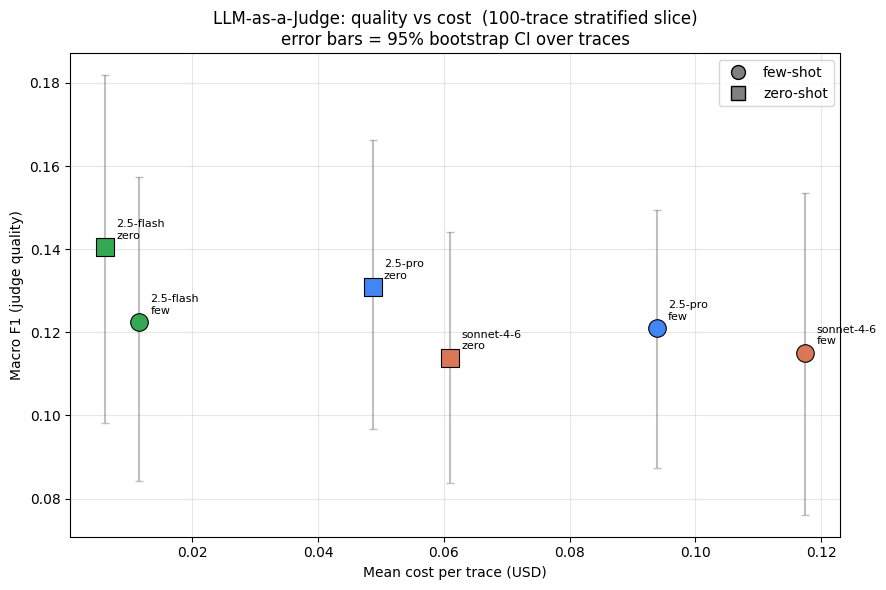

Saved: saved_results/comparison_figure.png


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

# color by model family, marker by shots
colors = {
    'claude-sonnet-4-6': '#D97757',
    'gemini-2.5-pro':    '#4285F4',
    'gemini-2.5-flash':  '#34A853',
}

for _, r in table.iterrows():
    is_few = 'few_shot' in r['config']
    ax.scatter(
        r['mean_cost_usd'], r['macro_F1'],
        s=160,
        color=colors.get(r['model'], 'gray'),
        marker='o' if is_few else 's',           # circle=few-shot, square=zero-shot
        edgecolor='black', linewidth=0.8,
        zorder=3,
    )
    # error bar on macro F1 (bootstrap CI over traces)
    ax.errorbar(
        r['mean_cost_usd'], r['macro_F1'],
        yerr=[[r['macro_F1'] - r['macro_F1_ci_lo']], [r['macro_F1_ci_hi'] - r['macro_F1']]],
        fmt='none', ecolor='gray', alpha=0.5, capsize=3, zorder=2,
    )
    # label
    shots = 'few' if is_few else 'zero'
    ax.annotate(f"{r['model'].replace('claude-','').replace('gemini-','')}\n{shots}",
                (r['mean_cost_usd'], r['macro_F1']),
                textcoords="offset points", xytext=(8, 6), fontsize=8)

ax.set_xlabel("Mean cost per trace (USD)")
ax.set_ylabel("Macro F1 (judge quality)")
ax.set_title("LLM-as-a-Judge: quality vs cost  (100-trace stratified slice)\nerror bars = 95% bootstrap CI over traces")
ax.grid(True, alpha=0.3)

# legend for shapes
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=10, label='few-shot'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=10, label='zero-shot'),
]
ax.legend(handles=legend_elems, loc='best')

plt.tight_layout()
plt.savefig("saved_results/comparison_figure.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: saved_results/comparison_figure.png")